# Article length statistics

Some newspapers are not scrapeable and need to be excluded. This is detectable via article length statistics.

## Important newspapers

In [1]:
from protest_impact.util import project_root
from protest_impact.data.news.config import newspapers_of_record, popular_newspapers, local_newspapers
from tqdm import tqdm
import matplotlib.pyplot as plt
import random
import pandas as pd

random.seed(20230126)
newspapers = newspapers_of_record + popular_newspapers + local_newspapers

lengths = []
for newspaper in tqdm(newspapers):
    path = project_root / "data" / "news" / "fulltext" / newspaper
    if path.exists():
        # get distribution of article lengths
        files = random.sample(list(path.glob("*/*.txt")), 1000)
        for file in files:
            with open(file) as f:
                text = f.read()
            lengths.append({"newspaper": newspaper, "length": len(text)})
df_main = pd.DataFrame(lengths)

100%|██████████| 39/39 [01:00<00:00,  1.55s/it]


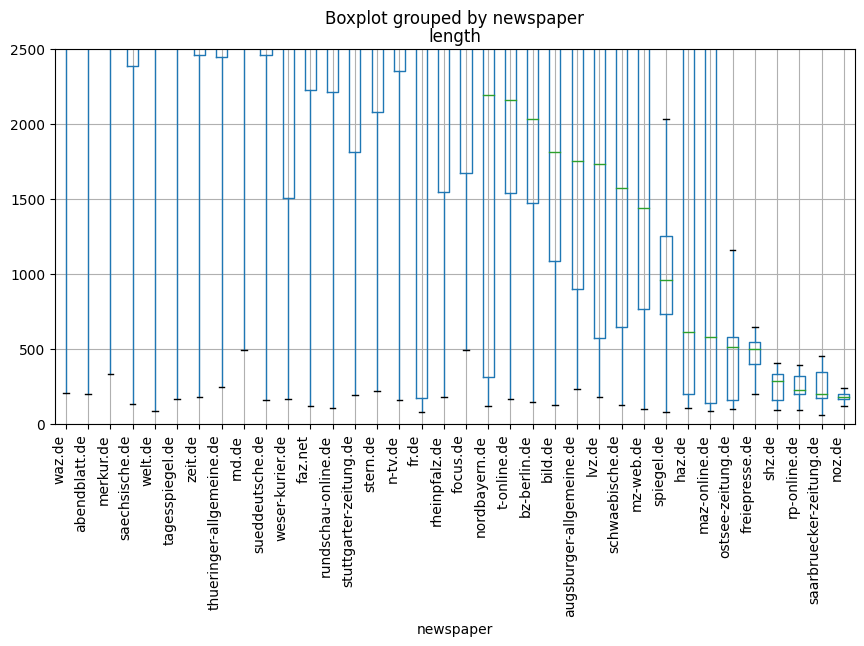

In [2]:
df = df_main.copy()
# plot distribution by newspaper (sorted by median length)
newspaper_order = df.groupby("newspaper").median().sort_values("length", ascending=False).index
# sort by newspaper order
df["newspaper"] = pd.Categorical(df["newspaper"], categories=newspaper_order)
# plot
fig, ax = plt.subplots(figsize=(10, 5))
# do not plot outliers
df.boxplot(column="length", by="newspaper", ax=ax, showfliers=False)
# rotate x labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, horizontalalignment="right")
# set y limits
ax.set_ylim(0, 2500)
plt.show()

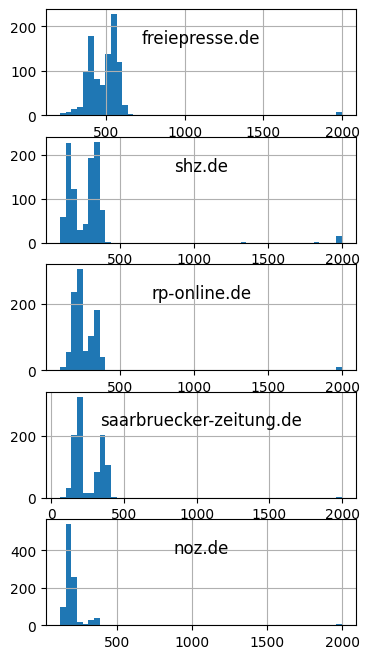

In [3]:
df = df_main.copy()
# cap at 2000 characters
df["length"] = df["length"].clip(upper=2000)
# plot histogram for each newspaper
n = 5
fig, axs = plt.subplots(n, 1, figsize=(4, 8))
for i, newspaper in enumerate(newspaper_order[-n:]):
    df[df["newspaper"] == newspaper]["length"].hist(ax=axs[i], bins=50)
    axs[i].set_title(newspaper, y=0.6)
plt.show()

## Mediacloud regional newspapers

In [4]:
from protest_impact.util.cache import get
from dotenv import load_dotenv
from os import environ
from protest_impact.types import NewsItem

load_dotenv()

def get_article_sample(media_id):
    response = get(
        "https://api.mediacloud.org/api/v2/stories_public/list/",
        params={
            "fq": f"media_id:{media_id}",
            "rows": "100", # max 1000
            "order": "random",
            "key": environ["MEDIACLOUD_API_KEY"],
        },
        headers={"Accept": "application/json"},
    )
    results = response.json()
    return [NewsItem.from_dict(result) for result in results]


In [5]:
from protest_impact.data.news.config import media_ids, filter_words
import json
from protest_impact.data.news.scraping import get_fulltext
from protest_impact.util import project_root
import pandas as pd
from tqdm.notebook import tqdm
from time import sleep

with open(project_root / "data" / "news" / "german_newspapers.json") as f:
    german_newspapers = json.load(f)
    
print(len(german_newspapers))

lengths = []
for i, newspaper in enumerate(german_newspapers):
    print(i, newspaper["name"])
    sample = get_article_sample(newspaper["media_id"])
    for article in sample:
        if not any(word in article.url for word in filter_words):
            try:
                article = get_fulltext(article)
                lengths.append({"newspaper": newspaper["name"], "length": len(article.content)})
            except:
                sleep(5)
                continue
df_lengths = pd.DataFrame(lengths)

134
0 hna
1 tz.de
2 merkur-online
3 Christ & Welt: ZEIT für Glaube, Geist und Gesellschaft
4 wn.de
5 Lokales und Nachrichten Ahlen - Westfälische Nachrichten ...
6 augsburger-allgemeine.de
7 kreiszeitung.de
8 op-online.de
9 echo-online.de
10 Bergsträßer Anzeiger
11 Schwetzinger Zeitung / Hockenheimer Zeitung
12 noz.de
13 mutig - offen - mittendrin -
14 Delmenhorster Kreisblatt
15 Hauptsache Heimat. -
16 AbendBlatt
17 Bersenbrücker Kreisblatt
18 Hier zu Hause -
19 Region Dillenburg - mittelhessen.de
20 Lokales - mittelhessen.de
21 Lokale Nachrichten aus Bürstadt, Lampertheim, Rhein-Neckar und Hessen - Bürstädter Zeitung
22 Lokale Nachrichten aus Wiesbaden, Rheingau, Taunus und Hessen - Wiesbadener Kurier
23 rga-online
24 nordbayern.de
25 Oberpfalznetz
26 Nachrichten aus Amberg - Onetz
27 Lokale Nachrichten aus Worms, Rhein-Neckar, dem Wonnegau und Rheinland-Pfalz - Wormser Zeitung
28 page - Solinger Tageblatt
29 Nachrichten aus Weiden - Onetz
30 Salzgitter Zeitung - Salzgitter Zeitung
3

In [6]:
df_lengths = pd.DataFrame(lengths)

IndexError: index 39 is out of bounds for axis 0 with size 39

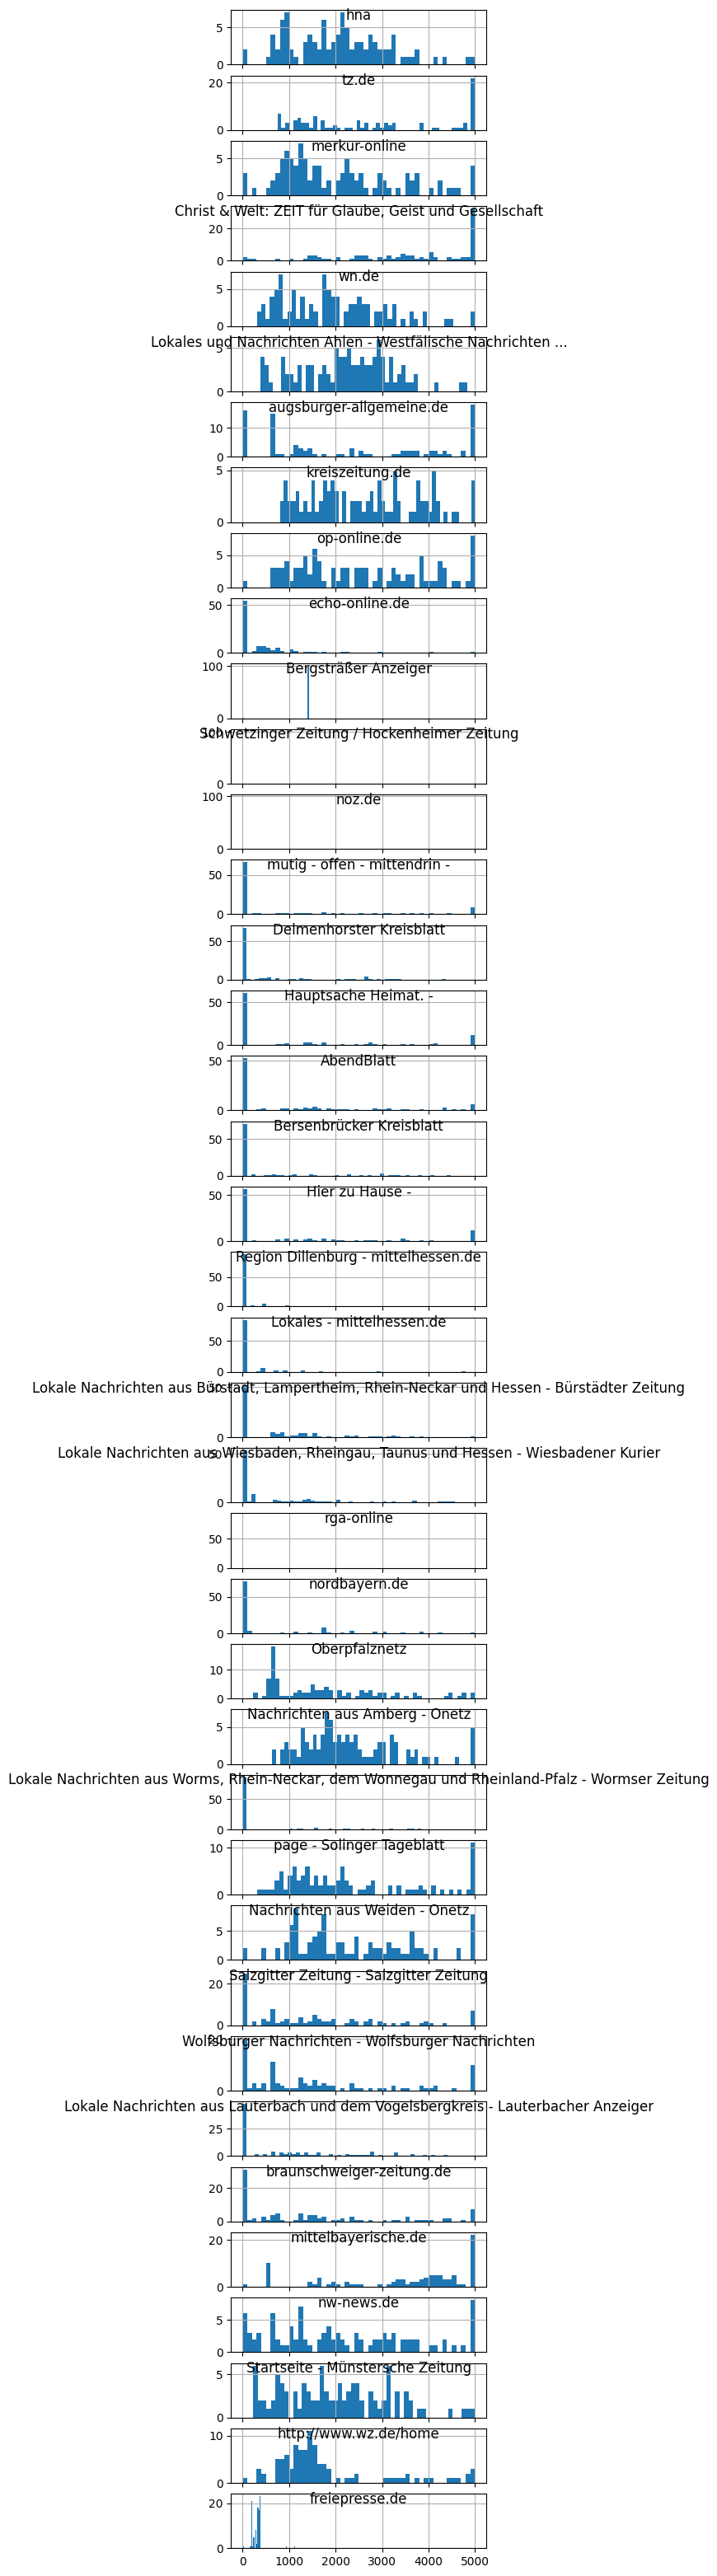

In [7]:
import matplotlib.pyplot as plt

# plot histogram for each newspaper
fig, axs = plt.subplots(len(newspapers), 1, figsize=(4, 40), sharex=True)
for i, newspaper in enumerate(german_newspapers):
    df= df_lengths.copy()
    df = df[df["newspaper"] == newspaper["name"]]["length"]
    df.clip(upper=5000).hist(ax=axs[i], bins=50)
    axs[i].set_title(newspaper["name"], y=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# def get_protest_articles(media_id, last_processed_stories_id=0):
#     num_rows = 1000
#     response = get(
#         "https://api.mediacloud.org/api/v2/stories_public/list/",
#         params={
#             "q": search_string[1:],
#             "fq": f"media_id:{media_id}",
#             "rows": num_rows, # max 1000
#             "last_processed_stories_id": last_processed_stories_id,
#             "key": environ["MEDIACLOUD_API_KEY"],
#         },
#         headers={"Accept": "application/json"},
#     )
#     result = response.json()
#     global intervals
#     intervals.append(time() - start)
#     if len(result) > 0.9 * num_rows:
#         last_processed_stories_id = result[-1]["processed_stories_id"]
#         result += get_protest_articles(media_id, last_processed_stories_id)
#     return result

In [ ]:
# import jsonlines
# import random

# random.seed("20230127")
# articles = random.sample(fulltexts, 500)

# with jsonlines.open(project_root / "data" / "news" / "german_protest_articles.jsonl", "w") as writer:
#     writer.write_all({"text": f.title + "\n\n" + f.content, "meta": {"date": f.date.isoformat(), "url": f.url}} for f in fulltexts)